# 🇧🇷 Projeto: Previsão do Câmbio USD/BRL — REGRESSÃO
## CRISP-DM — Etapas 3, 4, 5 e 6
**Disciplina:** Projeto Integrado de Ciência de Dados

---
### Objetivo
Prever o **valor contínuo do câmbio USD/BRL** (`usd_brl`) a partir de indicadores
macroeconômicos do Brasil entre 1995 e 2025, usando **Regressão** (Random Forest Regressor).

> ⚠️ **Regressão x Classificação:** este projeto prevê um **número contínuo** (a cotação do dólar),
> portanto NÃO usa matriz de confusão nem accuracy. As métricas corretas são **R², MAE e RMSE**.

---

## BLOCO 1 — Instalação e Importação de Bibliotecas

In [1]:
# Instalação (necessário apenas no Colab)
!pip install scikit-learn pandas matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


## BLOCO 2 — Carregamento e Exploração dos Dados

In [2]:
# No Colab: faça o upload manual do arquivo brazil_macro_dataset_synthetic_1995_2025.csv
df = pd.read_csv('brazil_macro_dataset_synthetic_1995_2025.csv')
df['date'] = pd.to_datetime(df['date'])

print('Shape do dataset:', df.shape)
print()
print('📋 Primeiras linhas:')
df.head()

Shape do dataset: (11323, 11)

📋 Primeiras linhas:


,date,ipca_monthly_pct,selic_rate_pct,usd_brl,gdp_growth_pct,unemployment_pct,fed_funds_rate_pct,us_inflation_pct,exports_usd,imports_usd,dxy_index
0,1995-01-01,0.424507,14.009255,1.649964,3.403253,7.184071,-0.208831,2.373734,1.331743e+10,1.812881e+10,93.500731
1,1995-01-02,0.329280,11.148793,1.059143,1.819950,8.970585,NaN,1.990825,1.399639e+10,2.436003e+10,93.915355
2,1995-01-03,0.447193,12.283418,2.062778,1.833144,9.597145,0.260132,2.110415,1.180461e+10,1.954295e+10,NaN
3,1995-01-04,0.578514,10.333014,3.188404,NaN,7.632133,2.839502,2.299810,1.493101e+10,2.170220e+10,104.123568
4,1995-01-05,0.314957,NaN,3.129469,4.829334,6.594602,1.800879,2.790339,2.570596e+10,2.489706e+10,82.811305


In [3]:
print('Informações das colunas:')
print(df.info())
print()
print('Estatísticas descritivas:')
df.describe()

Informações das colunas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11323 entries, 0 to 11322
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                11323 non-null  datetime64[ns]
 1   ipca_monthly_pct    11009 non-null  float64       
 2   selic_rate_pct      11014 non-null  float64       
 3   usd_brl             10960 non-null  float64       
 4   gdp_growth_pct      10984 non-null  float64       
 5   unemployment_pct    11010 non-null  float64       
 6   fed_funds_rate_pct  10967 non-null  float64       
 7   us_inflation_pct    11016 non-null  float64       
 8   exports_usd         10989 non-null  float64       
 9   imports_usd         10953 non-null  float64       
 10  dxy_index           10994 non-null  float64       
dtypes: datetime64[ns](1), float64(10)
memory usage: 973.2 KB
None

Estatísticas descritivas:


,date,ipca_monthly_pct,selic_rate_pct,usd_brl,gdp_growth_pct,unemployment_pct,fed_funds_rate_pct,us_inflation_pct,exports_usd,imports_usd,dxy_index
count,11323,11009.000000,11014.000000,10960.000000,10984.000000,11010.000000,10967.000000,11016.000000,1.098900e+04,1.095300e+04,10994.000000
mean,2010-07-02 00:00:00,0.466826,8.371045,3.367809,2.501409,8.988603,2.514920,2.195509,2.004454e+10,1.796494e+10,95.096635
min,1995-01-01 00:00:00,-0.130950,-2.489016,1.047227,-2.654469,2.157241,-1.226141,-0.477781,2.865085e+09,-5.257500e+08,68.521691
25%,2002-10-01 12:00:00,0.353924,6.518533,2.848634,1.691034,7.637640,1.831590,1.787832,1.674817e+10,1.461379e+10,90.401465
50%,2010-07-02 00:00:00,0.463593,8.332626,3.345450,2.505584,9.001482,2.521778,2.192912,1.998905e+10,1.795844e+10,95.147639
75%,2018-04-01 12:00:00,0.574255,10.207339,3.844187,3.310469,10.356174,3.191233,2.603909,2.334461e+10,2.132333e+10,99.820735
max,2025-12-31 00:00:00,3.361966,33.548385,14.181436,6.743838,16.490758,5.995113,4.456093,3.914891e+10,3.683090e+10,124.414181
std,NaN,0.178874,2.790382,0.779431,1.189721,2.016353,0.998637,0.602844,5.003186e+09,4.981869e+09,6.952777


In [4]:
print('Valores nulos por coluna:')
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)
pd.DataFrame({'Nulos': nulos, '% do Total': pct_nulos})

Valores nulos por coluna:


,Nulos,% do Total
date,0,0.00
ipca_monthly_pct,314,2.77
selic_rate_pct,309,2.73
usd_brl,363,3.21
gdp_growth_pct,339,2.99
unemployment_pct,313,2.76
fed_funds_rate_pct,356,3.14
us_inflation_pct,307,2.71
exports_usd,334,2.95
imports_usd,370,3.27


## BLOCO 3 — Preparação dos Dados (Data Preparation)

O alvo (**y**) é `usd_brl`. As features (**X**) são todos os demais indicadores
macroeconômicos. Removemos a coluna `date` da modelagem (mas guardamos para o Power BI).

In [5]:
# Remove linhas com valores nulos (modelo de regressão exige dados completos)
df_modelo = df.dropna().copy()
print(f'Registros após limpeza: {len(df_modelo)}')

TARGET = 'usd_brl'

# X = features | y = alvo contínuo
features = ['ipca_monthly_pct','selic_rate_pct','gdp_growth_pct','unemployment_pct',
            'fed_funds_rate_pct','us_inflation_pct','exports_usd','imports_usd','dxy_index']

X = df_modelo[features]
y = df_modelo[TARGET]

print('Features utilizadas:')
for c in features: print('   •', c)
print(f'\nAlvo (contínuo): {TARGET}')
print(f'Média do alvo: R$ {y.mean():.3f}  |  Min: {y.min():.3f}  |  Max: {y.max():.3f}')

Registros após limpeza: 8402
Features utilizadas:
   • ipca_monthly_pct
   • selic_rate_pct
   • gdp_growth_pct
   • unemployment_pct
   • fed_funds_rate_pct
   • us_inflation_pct
   • exports_usd
   • imports_usd
   • dxy_index

Alvo (contínuo): usd_brl
Média do alvo: R$ 3.369  |  Min: 1.047  |  Max: 14.181


In [6]:
# Divisão treino/teste + normalização
X_train, X_test, y_train, y_test, d_train, d_test = train_test_split(
    X, y, df_modelo['date'], test_size=0.2, random_state=42
)
print(f'Dados de TREINO: {X_train.shape[0]} registros')
print(f'Dados de TESTE:  {X_test.shape[0]} registros')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('\nDados normalizados com sucesso!')

Dados de TREINO: 6721 registros
Dados de TESTE:  1681 registros

Dados normalizados com sucesso!


## BLOCO 4 — Modelagem (Treinamento do Modelo de Regressão)

In [7]:
modelo = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42
)
modelo.fit(X_train_scaled, y_train)

print('Modelo de REGRESSÃO treinado com sucesso!')
print('   Algoritmo: Random Forest Regressor')
print('   Nº de árvores: 200')
print('   Profundidade máxima: 12')

Modelo de REGRESSÃO treinado com sucesso!
   Algoritmo: Random Forest Regressor
   Nº de árvores: 200
   Profundidade máxima: 12


## BLOCO 5 — Validação do Modelo (Etapa 5 do CRISP-DM)

Em regressão usamos:
- **R² (coeficiente de determinação):** quanto da variação do dólar o modelo explica (0 a 1).
- **MAE (erro absoluto médio):** erro médio em R$.
- **RMSE (raiz do erro quadrático médio):** penaliza erros grandes, em R$.

In [8]:
y_pred = modelo.predict(X_test_scaled)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

metricas = pd.DataFrame({
    'Métrica': ['R²','MAE (R$)','RMSE (R$)','MAPE (%)'],
    'Valor':   [round(r2,4), round(mae,4), round(rmse,4), round(mape,2)],
    'Descrição': [
        'Proporção da variância do câmbio explicada pelo modelo (0 a 1)',
        'Erro médio absoluto, em reais',
        'Raiz do erro quadrático médio, penaliza erros grandes',
        'Erro percentual absoluto médio'
    ]
})
print(metricas.to_string(index=False))

  Métrica   Valor                                                      Descrição
       R²  0.2266 Proporção da variância do câmbio explicada pelo modelo (0 a 1)
 MAE (R$)  0.5396                                  Erro médio absoluto, em reais
RMSE (R$)  0.6881          Raiz do erro quadrático médio, penaliza erros grandes
 MAPE (%) 17.7300                                 Erro percentual absoluto médio


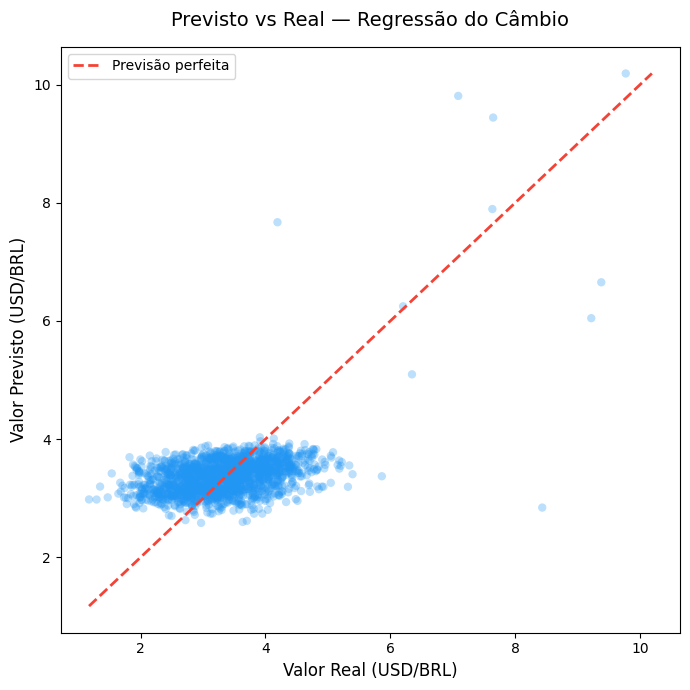

Gráfico salvo: grafico_previsto_vs_real.png


In [9]:
# Gráfico 1: Previsto vs Real (dispersão) — o ideal é cair sobre a linha diagonal
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.3, color='#2196F3', edgecolor='none')
lims=[min(y_test.min(),y_pred.min()), max(y_test.max(),y_pred.max())]
plt.plot(lims, lims, '--', color='#F44336', linewidth=2, label='Previsão perfeita')
plt.xlabel('Valor Real (USD/BRL)', fontsize=12)
plt.ylabel('Valor Previsto (USD/BRL)', fontsize=12)
plt.title('Previsto vs Real — Regressão do Câmbio', fontsize=14, pad=15)
plt.legend()
plt.tight_layout()
plt.savefig('grafico_previsto_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo: grafico_previsto_vs_real.png')

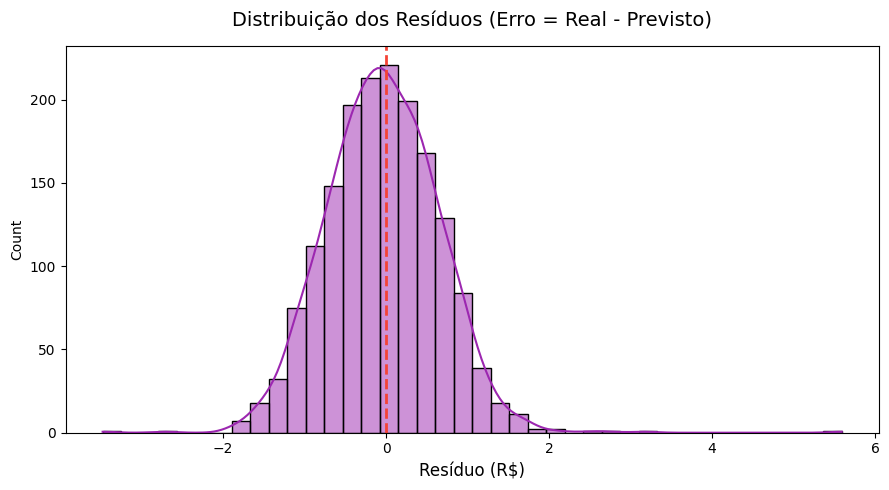

Gráfico salvo: grafico_residuos.png


In [10]:
# Gráfico 2: Distribuição dos resíduos (erros)
residuos = y_test - y_pred
plt.figure(figsize=(9,5))
sns.histplot(residuos, bins=40, color='#9C27B0', kde=True)
plt.axvline(0, color='#F44336', linestyle='--', linewidth=2)
plt.title('Distribuição dos Resíduos (Erro = Real - Previsto)', fontsize=14, pad=15)
plt.xlabel('Resíduo (R$)', fontsize=12)
plt.tight_layout()
plt.savefig('grafico_residuos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo: grafico_residuos.png')

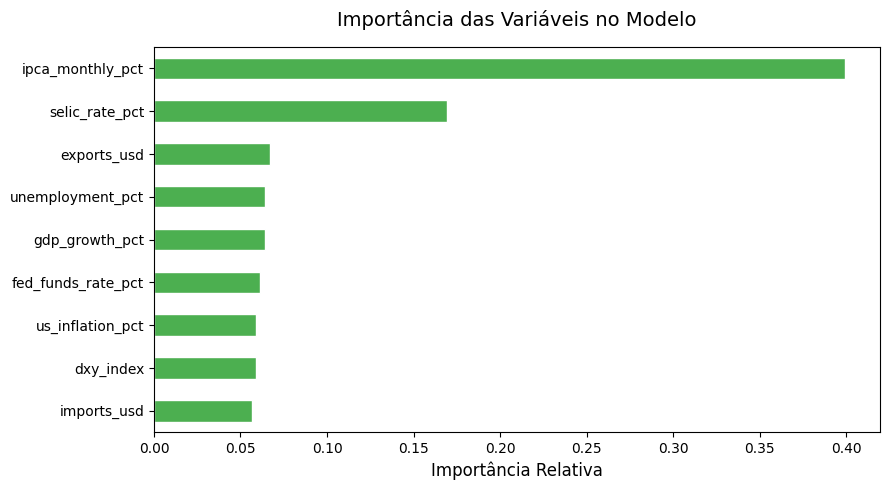

Gráfico salvo: grafico_importancia_features.png


In [11]:
# Gráfico 3: Importância das variáveis
importancias = pd.Series(modelo.feature_importances_, index=features).sort_values()
plt.figure(figsize=(9,5))
importancias.plot(kind='barh', color='#4CAF50', edgecolor='white')
plt.title('Importância das Variáveis no Modelo', fontsize=14, pad=15)
plt.xlabel('Importância Relativa', fontsize=12)
plt.tight_layout()
plt.savefig('grafico_importancia_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo: grafico_importancia_features.png')

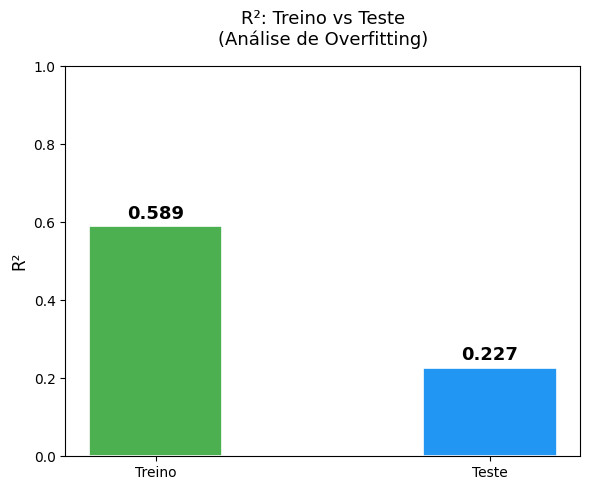

Gráfico salvo: grafico_overfitting.png


In [12]:
# Análise de overfitting: R² treino vs teste
r2_treino = r2_score(y_train, modelo.predict(X_train_scaled))
r2_teste  = r2
plt.figure(figsize=(6,5))
plt.bar(['Treino','Teste'], [r2_treino, r2_teste],
        color=['#4CAF50','#2196F3'], edgecolor='white', linewidth=1.2, width=0.4)
plt.ylim(0,1.0)
plt.title('R²: Treino vs Teste\n(Análise de Overfitting)', fontsize=13, pad=15)
plt.ylabel('R²', fontsize=12)
for i,v in enumerate([r2_treino,r2_teste]):
    plt.text(i, v+0.02, f'{v:.3f}', ha='center', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('grafico_overfitting.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo: grafico_overfitting.png')

## BLOCO 6 — Exportação dos Resultados (para Power BI)

In [13]:
# Tabela de previsões linha a linha (vai virar a tabela-fato no Power BI)
resultados = pd.DataFrame({
    'date':     d_test.values,
    'Real':     y_test.values,
    'Previsto': y_pred
})
resultados['Erro']     = resultados['Real'] - resultados['Previsto']
resultados['Erro_Abs'] = resultados['Erro'].abs()
resultados['Erro_Pct'] = (resultados['Erro_Abs'] / resultados['Real'] * 100)
resultados = resultados.sort_values('date')
resultados.to_csv('resultados_regressao.csv', index=False)
print('Arquivo salvo: resultados_regressao.csv')

# Métricas
metricas_export = pd.DataFrame({
    'Metrica': ['R2','MAE','RMSE','MAPE_pct'],
    'Valor':   [round(r2,4), round(mae,4), round(rmse,4), round(mape,2)]
})
metricas_export.to_csv('metricas_regressao.csv', index=False)
print('Arquivo salvo: metricas_regressao.csv')

# Importância das variáveis
imp_export = pd.Series(modelo.feature_importances_, index=features).sort_values(ascending=False)
imp_export = imp_export.reset_index()
imp_export.columns = ['Variavel','Importancia']
imp_export.to_csv('importancia_regressao.csv', index=False)
print('Arquivo salvo: importancia_regressao.csv')

Arquivo salvo: resultados_regressao.csv
Arquivo salvo: metricas_regressao.csv
Arquivo salvo: importancia_regressao.csv


---
## BLOCO 7 — Resumo Final dos Resultados

In [15]:
print('=' * 60)
print('           RESUMO FINAL DO PROJETO (REGRESSÃO)')
print('=' * 60)
print(f'  Dataset:     Indicadores Macroeconômicos do Brasil')
print(f'  Período:     1995 - 2025')
print(f'  Registros:   {len(df_modelo):,}')
print(f'  Alvo:        usd_brl (câmbio USD/BRL - contínuo)')
print(f'  Algoritmo:   Random Forest Regressor')
print()
print(f'  MÉTRICAS DE DESEMPENHO:')
print(f'  - R²:    {r2:.4f}')
print(f'  - MAE:   R$ {mae:.4f}')
print(f'  - RMSE:  R$ {rmse:.4f}')
print(f'  - MAPE:  {mape:.2f}%')
print()

           RESUMO FINAL DO PROJETO (REGRESSÃO)
  Dataset:     Indicadores Macroeconômicos do Brasil
  Período:     1995 - 2025
  Registros:   8,402
  Alvo:        usd_brl (câmbio USD/BRL - contínuo)
  Algoritmo:   Random Forest Regressor

  MÉTRICAS DE DESEMPENHO:
  - R²:    0.2266
  - MAE:   R$ 0.5396
  - RMSE:  R$ 0.6881
  - MAPE:  17.73%

